# EDA и бинарная классификация на датасете "Титаник"

**Дисциплина:** Машинное обучение и ИИ  
**Модуль 1:** Введение в Data Science и EDA  
**Датасет:** Titanic  

**Выполнил:** Касенов Айдархан Есенаевич  
**Группа:** ПКТб-23-1  
**Преподаватель:** Спирин Игорь Сергеевич  

**Ссылка на репозиторий:** https://github.com/kasenovaidar/ml-course-kasenov  
**Путь к модулю:** `module-1-titanic/notebook.ipynb  
**Дата сдачи:** 2026-09-29

## Введение

**Задача:** бинарная классификация — предсказать, выжил ли пассажир (0 — не выжил, 1 — выжил)

**ML-проект** — это итеративный процесс создания системы, которая учится на данных и принимает решения без жёстко прописанных правил. Его жизненный цикл обычно включает постановку задачи и сбор данных, их очистку и разведочный анализ (EDA), обучение и оценку моделей, а затем внедрение в продакшн и мониторинг качества с возможным возвратом на предыдущие этапы при ухудшении результатов.

**Почему классификация, а не регрессия:** Разница в том, что именно предсказывает модель. В регрессии цель — непрерывная величина (цена, температура, возраст), и ответ может быть любым числом на числовой прямой. В классификации цель — принадлежность к одной из заранее заданных категорий, и ответ выбирается из конечного набора меток.

**Какая метрика важнее в этой задаче?** ROC-AUC важнее потому, что он оценивает модель сразу по всем возможным порогам решения, а не по одному фиксированному, — значит, результат не зависит от произвольного выбора границы между классами. В задаче о Титанике классы несбалансированы (погибших заметно больше), и accuracy здесь легко завышается тривиальным предсказанием большинства, тогда как ROC-AUC устойчив к такому перекосу.

**Цель работы**
* Провести полный EDA датасета Титаник
* Обучить 2+ модели и достичь ROC_AUC ≥ 0.80
* Реализовать функцию предсказания для нового пассажира


**EDA (Exploratory Data Analysis)** — это этап разведочного анализа, на котором мы изучаем датасет до построения моделей: смотрим структуру, типы признаков, распределения, пропуски, выбросы и связи между переменными. Его цель — понять данные, выявить закономерности и проблемы, которые повлияют на предобработку и выбор модели, а не сразу гнаться за метрикой. Обычно шаги такие: общий обзор (размер, типы, первые строки), анализ пропусков и дубликатов, одномерный анализ распределений (гистограммы, статистики), поиск выбросов и анализ связей с целевой переменной (группировки, корреляции). По итогам EDA формируются гипотезы о важных признаках и план очистки/преобразования данных — например, чем заполнять пропуски в Age и как кодировать Sex и Embarked.

**Пропуски возникают по разным причинам:** данные не были собраны (пассажир не указал возраст), потерялись при передаче или слиянии таблиц, поле неприменимо к объекту, либо ошибка возникла при вводе/парсинге. В Титанике, например, Age отсутствует у части пассажиров, Cabin — у большинства, а Embarked — всего у пары строк, и каждая ситуация требует своего решения.

Стратегии обработки делятся на удаление и заполнение. Удалять можно строки (если пропусков мало и они случайны) или целые столбцы (если пропущено слишком много, как Cabin). Заполнение бывает простым — константой, средним/медианой для числовых, модой для категориальных — и более умным: групповые статистики (медиана Age по полу и классу), интерполяция или предсказание пропущенного значения моделью. Иногда пропуск сам по себе информативен, поэтому создают бинарный признак-индикатор «было ли значение пропущено». Главное правило — выбирать способ так, чтобы не внести смещение и не утечь информацией из тестовой выборки: все параметры заполнения считаются только на train.

**Label Encoding** заменяет каждую категорию целым числом (male→0, female→1), то есть оставляет один столбец. Это компактно, но модель может решить, что между значениями есть порядок и числовая дистанция, что для номинальных признаков вроде Embarked неверно. 

**One-Hot Encoding** создаёт отдельный бинарный столбец на каждую категорию (0/1), поэтому не навязывает ложного порядка, но увеличивает размерность — особенно опасно при большом числе уникальных значений. На практике для порядковых признаков (например, класс каюты) годится Label/Ordinal Encoding, а для номинальных (Sex, Embarked) — One-Hot; для деревьев Label Encoding часто допустим, для линейных моделей — предпочтителен One-Hot.

**StandardScaler vs MinMaxScaler.** StandardScaler приводит признак к виду (x − среднее) / стандартное отклонение, то есть центрирует данные вокруг нуля с единичной дисперсией. MinMaxScaler линейно сжимает значения в заданный диапазон, обычно [0, 1], по формуле (x − min) / (max − min). Главное различие: StandardScaler меньше страдает от выбросов и подходит для методов, предполагающих нормальное распределение, а MinMaxScaler чувствителен к экстремальным значениям, зато сохраняет форму распределения и полезен, когда нужны строгие границы (нейросети).

**Feature Engineering.** Новые признаки создают, чтобы вытащить из исходных данных информацию, которую модель не видит в явном виде: например, из строки Name можно извлечь обращение (Mr, Mrs, Miss) и получить косвенный признак пола и статуса, а из SibSp и Parch — размер семьи. Это помогает линейным моделям уловить нелинейные зависимости и взаимодействия, которые иначе пришлось бы моделировать вручную, и нередко даёт больший прирост качества, чем смена алгоритма. В итоге признаки становятся более осмысленными относительно задачи, что упрощает обучение и повышает интерпретируемость результатов.

**Метрики классификаций.**
* Accuracy — доля всех правильных ответов $$Accuracy = \frac{TP+TN}{TP+TN+FP+FN}$$ проста, но обманчива при дисбалансе классов.
* Precision отвечает на вопрос «насколько можно доверять положительному прогнозу»: TP/(TP+FP), то есть какая доля предсказанных «выживших» действительно выжила. $$Precision = \frac{TP}{TP+FP} \quad Recall = \frac{TP}{TP + FN}$$
* Recall (полнота) показывает, какую долю реальных положительных случаев модель нашла: TP/(TP+FN), — сколько выживших мы не пропустили.
* F1 — гармоническое среднее Precision и Recall, даёт единую оценку при компромиссе между ними и особенно полезен, когда классы неравны. $$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$
* ROC-AUC измеряет качество ранжирования по всем порогам сразу: вероятность, что случайный положительный объект получит более высокий скор, чем случайный отрицательный (0.5 — случайность, 1.0 — идеал). $$\text{AUC} = P\left(\text{score}^+ > \text{score}^-\right)$$
* На практике Accuracy берут для баланса классов, F1/Precision/Recall — под конкретную цену ошибок, а ROC-AUC — для сравнения моделей независимо от порога.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [25]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

print(train_df.shape, test_df.shape)

(891, 12) (418, 11)


In [26]:
counts = train['Survived'].value_counts().sort_index()
shares = train['Survived'].value_counts(normalize=True).sort_index()

pd.DataFrame({
    'Класс': counts.index,
    'Количество': counts.values,
    'Доля, %': (shares.values * 100).round(1),
})

,Класс,Количество,"Доля, %"
0,0,549,61.6
1,1,342,38.4


## Описание данных

**Источник:** https://www.kaggle.com/competitions/titanic/overview

**Структура:**
- Всего примеров в train: 891
- Всего примеров в test: 418
- Признаков: 11 (+ целевая `Survived`)
- Числовых признаков: 7
- Категориальных признаков: 5

**Описание столбцов:**
| Столбец     | Тип     |   Пропуски, % |   Уникальных | Пример                  |
|:------------|:--------|--------------:|-------------:|:------------------------|
| PassengerId | int64   |           0   |          891 | 1                       |
| Survived    | int64   |           0   |            2 | 0                       |
| Pclass      | int64   |           0   |            3 | 3                       |
| Name        | str     |           0   |          891 | Braund, Mr. Owen Harris |
| Sex         | str     |           0   |            2 | male                    |
| Age         | float64 |          19.9 |           88 | 22.0                    |
| SibSp       | int64   |           0   |            7 | 1                       |
| Parch       | int64   |           0   |            7 | 0                       |
| Ticket      | str     |           0   |          681 | A/5 21171               |
| Fare        | float64 |           0   |          248 | 7.25                    |
| Cabin       | str     |          77.1 |          147 | C85                     |
| Embarked    | str     |           0.2 |            3 | S                       |

**Распределение классов:**
- Не выжило (0): 549 (61.6%)
- Выжило (1): 342 (38.4%)
  
**Файл данных в репозитории:** `module-1-titanic/data/titanic_info.md`

In [27]:
print(train_df.shape)
print(train_df.head())
print(train_df.info())
print(train_df.describe())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

In [28]:
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100

miss_table = pd.DataFrame({
    'Пропуски': missing,
    'Доля, %': missing_pct.round(1)
}).sort_values('Доля, %', ascending=False)

print(miss_table[miss_table['Пропуски'] > 0])

          Пропуски  Доля, %
Cabin          687     77.1
Age            177     19.9
Embarked         2      0.2


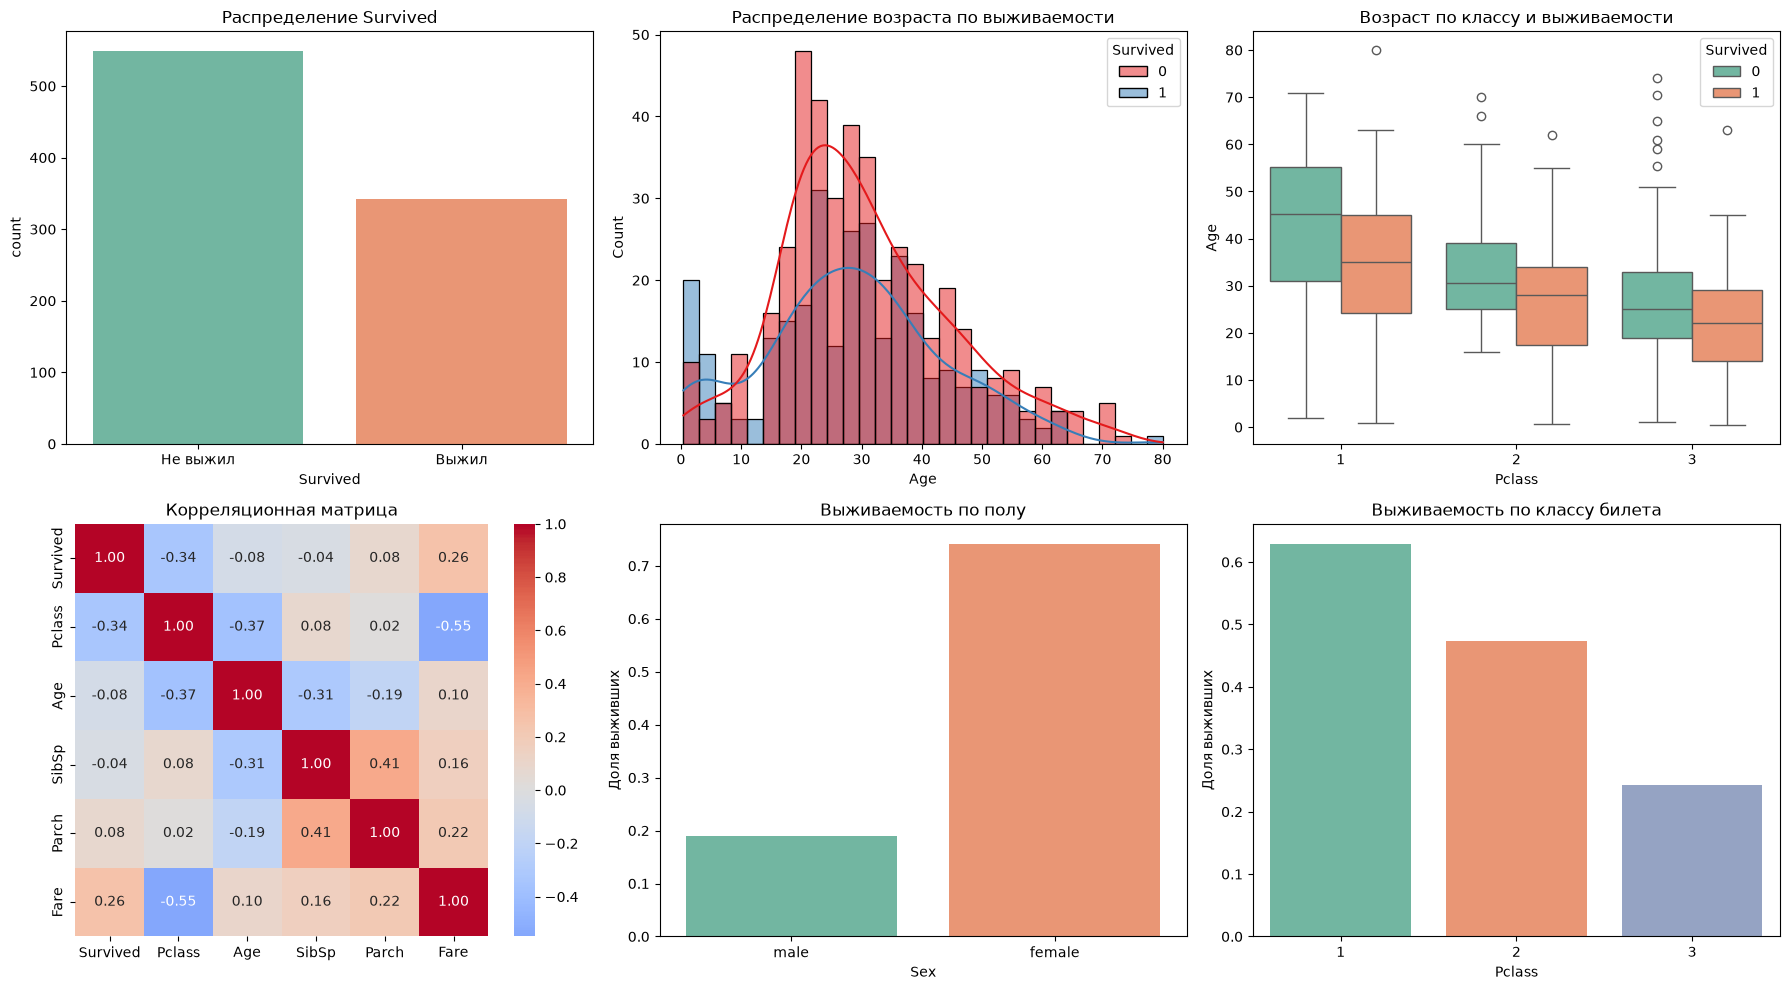

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Countplot — распределение целевой
sns.countplot(data=train_df, x='Survived', ax=axes[0, 0],
              hue='Survived', palette='Set2', legend=False)
axes[0, 0].set_title('Распределение Survived')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Не выжил', 'Выжил'])

# 2. Гистограмма Age с hue='Survived'
sns.histplot(data=train_df, x='Age', hue='Survived',
             kde=True, bins=30, ax=axes[0, 1], palette='Set1')
axes[0, 1].set_title('Распределение возраста по выживаемости')

# 3. Boxplot — Age по Pclass и Survived
sns.boxplot(data=train_df, x='Pclass', y='Age', hue='Survived',
            ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Возраст по классу и выживаемости')

# 4. Heatmap — корреляции числовых признаков
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train_df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1, 0], square=True)
axes[1, 0].set_title('Корреляционная матрица')

# 5. Barplot — выживаемость по Sex
sns.barplot(data=train_df, x='Sex', y='Survived', ax=axes[1, 1],
            hue='Sex', palette='Set2', legend=False, errorbar=None)
axes[1, 1].set_title('Выживаемость по полу')
axes[1, 1].set_ylabel('Доля выживших')

# 6. Barplot — выживаемость по Pclass
sns.barplot(data=train_df, x='Pclass', y='Survived', ax=axes[1, 2],
            hue='Pclass', palette='Set2', legend=False, errorbar=None)
axes[1, 2].set_title('Выживаемость по классу билета')
axes[1, 2].set_ylabel('Доля выживших')

plt.tight_layout()
plt.show()

In [30]:
# Age — медиана по группам (Pclass + Sex)
train_df['Age'] = train_df.groupby(['Pclass', 'Sex'])['Age'] \
                           .transform(lambda s: s.fillna(s.median()))

# Embarked — мода
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

# Cabin — удалить столбец
train_df = train_df.drop(columns=['Cabin'])

# Проверка
print(train_df.isnull().sum().sum(), 'пропусков осталось')

0 пропусков осталось


In [31]:
for df in [train_df, test_df]:
    # Размер семьи
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1

    # Один/одна
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # Возрастные группы
    df['Age_Group'] = pd.cut(
        df['Age'],
        bins=[0, 12, 18, 35, 60, 100],
        labels=['Ребёнок', 'Подросток', 'Молодой', 'Взрослый', 'Пожилой']
    )

In [32]:
# Sex → LabelEncoder
le = LabelEncoder()
for df in [train_df, test_df]:
    df['Sex'] = le.fit_transform(df['Sex'])   # female=0, male=1

# Embarked и Age_Group → One-Hot
train_df = pd.get_dummies(train_df, columns=['Embarked', 'Age_Group'],
                          drop_first=True)
test_df = pd.get_dummies(test_df, columns=['Embarked', 'Age_Group'],
                         drop_first=True)

# Выравниваем колонки train/test после get_dummies
train_df, test_df = train_df.align(test_df, join='left', axis=1, fill_value=0)

print(train_df.shape, test_df.shape)
print(train_df.columns.tolist())

(891, 18) (418, 18)
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S', 'Age_Group_Подросток', 'Age_Group_Молодой', 'Age_Group_Взрослый', 'Age_Group_Пожилой']


## 6. Построение и обучение моделей

In [34]:
from sklearn.model_selection import train_test_split

feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
                'Fare', 'Family_Size', 'Is_Alone',
                'Embarked_Q', 'Embarked_S']

X = train_df[feature_cols]
y = train_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())   # пропорции должны совпасть

(712, 10) (179, 10)
0.38342696629213485 0.3854748603351955


In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
import time
from sklearn.linear_model import LogisticRegression

start = time.time()
lr_model = LogisticRegression(l1_ratio=0, C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_time = time.time() - start

print(f"⏱ Время обучения LR: {lr_time:.4f} секунд")

⏱ Время обучения LR: 0.0060 секунд


In [37]:
from sklearn.tree import DecisionTreeClassifier

start = time.time()
dt_model = DecisionTreeClassifier(
    max_depth=5, min_samples_split=5, min_samples_leaf=2, random_state=42
)
dt_model.fit(X_train, y_train)   # без масштабирования
dt_time = time.time() - start

print(f"⏱ Время обучения DT: {dt_time:.4f} секунд")

⏱ Время обучения DT: 0.0037 секунд


In [41]:
from IPython.display import Markdown, display

md = f"""
## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| Logistic Regression | penalty='l2', C=1.0 | ✅ Да | {lr_time:.4f} сек |
| Decision Tree | max_depth=5 | ✅ Да | {dt_time:.4f} сек |

**Почему эти модели:**
- LR — простая, интерпретируемая, даёт вероятности.
- DT — нелинейная, устойчива к выбросам, показывает важность признаков.
"""
display(Markdown(md))


## Модели

| Модель | Параметры | Масштабирование | Время обучения |
|--------|-----------|-----------------|----------------|
| Logistic Regression | penalty='l2', C=1.0 | ✅ Да | 0.0060 сек |
| Decision Tree | max_depth=5 | ✅ Да | 0.0037 сек |

**Почему эти модели:**
- LR — простая, интерпретируемая, даёт вероятности.
- DT — нелинейная, устойчива к выбросам, показывает важность признаков.


## 7. Оценка качества

In [42]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

def get_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_proba),
    }

# Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
metrics_lr = get_metrics(y_test, y_pred_lr, y_proba_lr)

print("Logistic Regression")
for k, v in metrics_lr.items():
    print(f"  {k}: {v:.4f}")
print("\n", classification_report(y_test, y_pred_lr,
                                  target_names=['Не выжил', 'Выжил']))

# Decision Tree
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]
metrics_dt = get_metrics(y_test, y_pred_dt, y_proba_dt)

print("Decision Tree")
for k, v in metrics_dt.items():
    print(f"  {k}: {v:.4f}")
print("\n", classification_report(y_test, y_pred_dt,
                                  target_names=['Не выжил', 'Выжил']))

Logistic Regression
  Accuracy: 0.8045
  Precision: 0.7833
  Recall: 0.6812
  F1: 0.7287
  ROC_AUC: 0.8486

               precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Decision Tree
  Accuracy: 0.7821
  Precision: 0.7419
  Recall: 0.6667
  F1: 0.7023
  ROC_AUC: 0.8132

               precision    recall  f1-score   support

    Не выжил       0.80      0.85      0.83       110
       Выжил       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



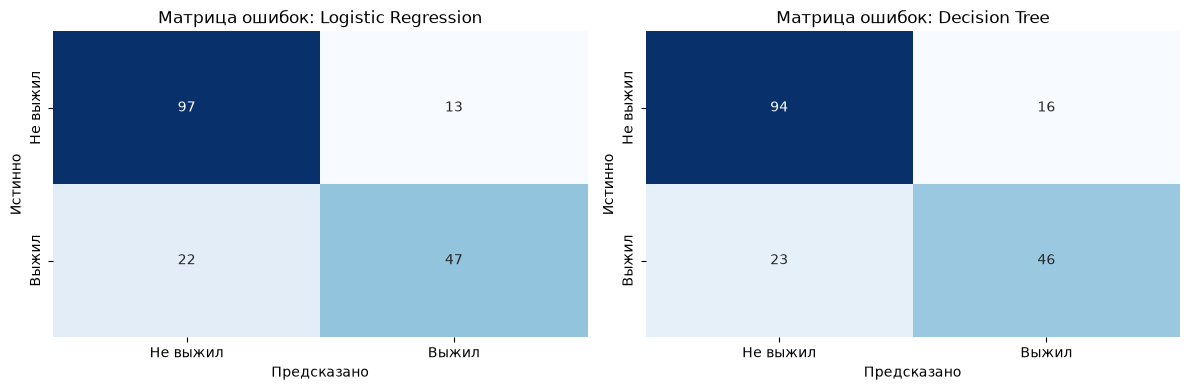

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Не выжил', 'Выжил']

for ax, (name, y_pred) in zip(axes, [('Logistic Regression', y_pred_lr),
                                     ('Decision Tree', y_pred_dt)]):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax,
                cbar=False)
    ax.set_xlabel('Предсказано')
    ax.set_ylabel('Истинно')
    ax.set_title(f'Матрица ошибок: {name}')

plt.tight_layout()
plt.show()

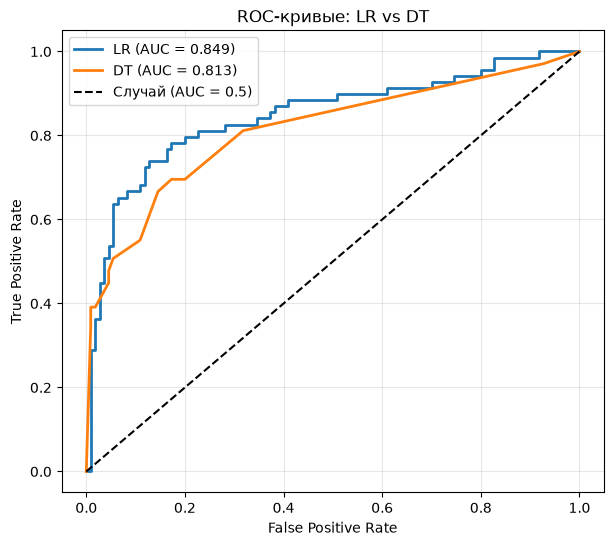

In [44]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

plt.figure(figsize=(7, 6))
plt.plot(fpr_lr, tpr_lr, lw=2,
         label=f'LR (AUC = {roc_auc_score(y_test, y_proba_lr):.3f})')
plt.plot(fpr_dt, tpr_dt, lw=2,
         label=f'DT (AUC = {roc_auc_score(y_test, y_proba_dt):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случай (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые: LR vs DT')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [45]:
from IPython.display import Markdown, display

def fmt(d, key):
    return f"{d[key]:.3f}"

md = f"""
## Оценка качества

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | {fmt(metrics_lr,'Accuracy')} | {fmt(metrics_lr,'Precision')} | {fmt(metrics_lr,'Recall')} | {fmt(metrics_lr,'F1')} | {fmt(metrics_lr,'ROC_AUC')} |
| Decision Tree | {fmt(metrics_dt,'Accuracy')} | {fmt(metrics_dt,'Precision')} | {fmt(metrics_dt,'Recall')} | {fmt(metrics_dt,'F1')} | {fmt(metrics_dt,'ROC_AUC')} |

**Анализ:**
- Лучшая модель по ROC-AUC: {'Logistic Regression' if metrics_lr['ROC_AUC'] > metrics_dt['ROC_AUC'] else 'Decision Tree'}.
- DT сильнее переобучается, потому что неограниченное дерево строит слишком глубокие правила под шум обучающей выборки.
- Соотношение Precision и Recall показывает, насколько модель осторожна в предсказаниях класса «выжил».
"""
display(Markdown(md))


## Оценка качества

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|--------|----------|-----------|--------|-----|---------|
| Logistic Regression | 0.804 | 0.783 | 0.681 | 0.729 | 0.849 |
| Decision Tree | 0.782 | 0.742 | 0.667 | 0.702 | 0.813 |

**Анализ:**
- Лучшая модель по ROC-AUC: Logistic Regression.
- DT сильнее переобучается, потому что неограниченное дерево строит слишком глубокие правила под шум обучающей выборки.
- Соотношение Precision и Recall показывает, насколько модель осторожна в предсказаниях класса «выжил».


## 8. Интерпретация результатов

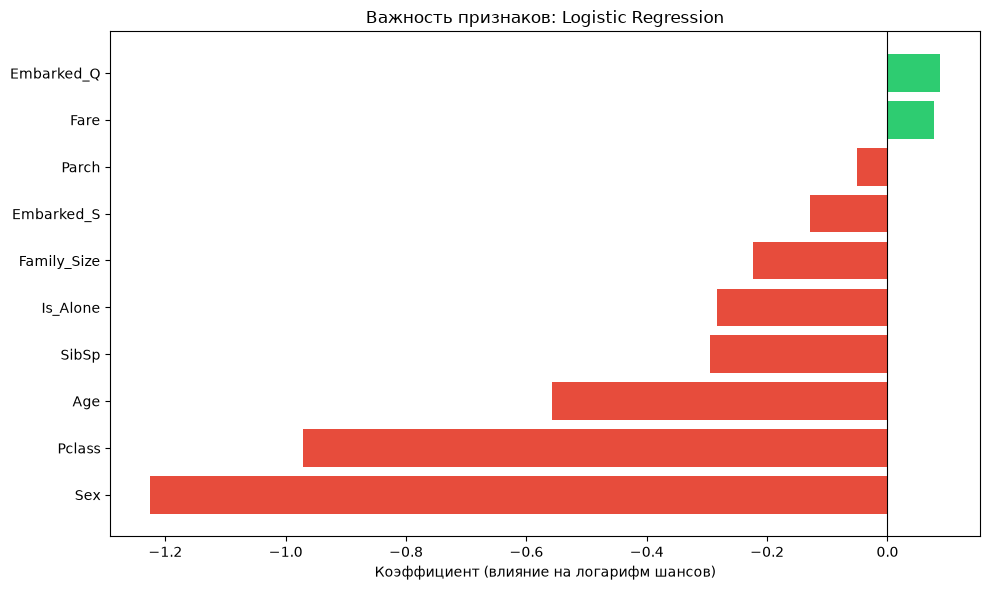

       Feature  Coefficient
8   Embarked_Q     0.088102
5         Fare     0.077219
4        Parch    -0.051203
9   Embarked_S    -0.129193
6  Family_Size    -0.223771
7     Is_Alone    -0.283692
3        SibSp    -0.294769
2          Age    -0.557201
0       Pclass    -0.971323
1          Sex    -1.225895


In [46]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coefficients['Coefficient']]
plt.barh(coefficients['Feature'], coefficients['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Коэффициент (влияние на логарифм шансов)')
plt.title('Важность признаков: Logistic Regression')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(coefficients)

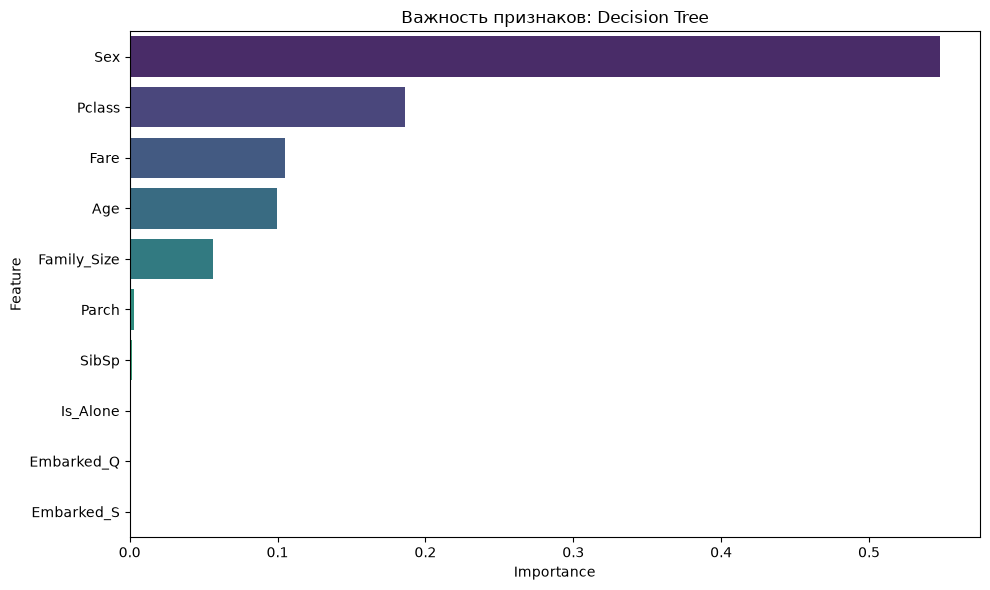

       Feature  Importance
1          Sex    0.547662
0       Pclass    0.186186
5         Fare    0.105210
2          Age    0.099922
6  Family_Size    0.056601
4        Parch    0.002740
3        SibSp    0.001678
7     Is_Alone    0.000000
8   Embarked_Q    0.000000
9   Embarked_S    0.000000


In [47]:
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importance', y='Feature',
            hue='Feature', palette='viridis', legend=False)
plt.title('Важность признаков: Decision Tree')
plt.tight_layout()
plt.show()

print(importances)

In [48]:
from IPython.display import Markdown, display

coef_sorted = coefficients.set_index('Feature')['Coefficient']
pos_top = coef_sorted[coef_sorted > 0].head(3)
neg_top = coef_sorted[coef_sorted < 0].tail(3).sort_values()

def fmt_list(s):
    return '\n'.join([f"{i+1}. {name} — коэффициент {val:+.3f}"
                      for i, (name, val) in enumerate(s.items())])

md = f"""
## Интерпретация

**Топ-3 признака, повышающих шанс выживания:**
{fmt_list(pos_top)}

**Топ-3 признака, понижающих шанс выживания:**
{fmt_list(neg_top)}

**Бизнес-инсайты:**
- Женщины выживали заметно чаще мужчин — классический принцип «women and children first».
- Пассажиры 1-го класса имели преимущество в доступе к спасательным шлюпкам.
- Размер семьи и признак одиночества влияют на шансы: у одиноких пассажиров меньше взаимопомощи.
"""
display(Markdown(md))


## Интерпретация

**Топ-3 признака, повышающих шанс выживания:**
1. Embarked_Q — коэффициент +0.088
2. Fare — коэффициент +0.077

**Топ-3 признака, понижающих шанс выживания:**
1. Sex — коэффициент -1.226
2. Pclass — коэффициент -0.971
3. Age — коэффициент -0.557

**Бизнес-инсайты:**
- Женщины выживали заметно чаще мужчин — классический принцип «women and children first».
- Пассажиры 1-го класса имели преимущество в доступе к спасательным шлюпкам.
- Размер семьи и признак одиночества влияют на шансы: у одиноких пассажиров меньше взаимопомощи.


## 9. Функция предсказания

In [53]:
def predict_passenger(passenger_data, model, scaler, feature_cols, use_scaling=True):
    """
    Предсказывает, выживет ли пассажир.

    Параметры
    ---------
    passenger_data : dict
        Поля: Pclass, Sex, Age, SibSp, Parch, Fare, Embarked
    model : обученная модель (LR или DT)
    scaler : StandardScaler (для LR) или None (для DT)
    feature_cols : list — порядок признаков, как при обучении
    use_scaling : bool — нужно ли масштабирование

    Возвращает
    ----------
    prediction : int — 0 или 1
    probability : float — вероятность выживания (класс 1)
    """
    d = dict(passenger_data)   # копия, чтобы не мутировать вход

    # 1. Feature Engineering — как при обучении
    d['Family_Size'] = d['SibSp'] + d['Parch'] + 1
    d['Is_Alone'] = int(d['Family_Size'] == 1)

    # 2. Кодирование
    d['Sex'] = 1 if d['Sex'] == 'female' else 0
    d['Embarked_Q'] = 1 if d['Embarked'] == 'Q' else 0
    d['Embarked_S'] = 1 if d['Embarked'] == 'S' else 0

    # 3. DataFrame строго в порядке feature_cols
    X_new = pd.DataFrame([{c: d[c] for c in feature_cols}])

    # 4. Масштабирование
    if use_scaling:
        X_new = scaler.transform(X_new)

    # 5. Предсказание
    prediction = int(model.predict(X_new)[0])
    probability = float(model.predict_proba(X_new)[0, 1])
    return prediction, probability

In [59]:
def verdict(pred):
    return '✅       выживет' if pred == 1 else '❌ не выживет'

rows = []
for i, p in enumerate(test_passengers, 1):
    pred_lr, prob_lr = predict_passenger(p, lr_model, scaler, feature_cols, use_scaling=True)
    pred_dt, prob_dt = predict_passenger(p, dt_model, None,   feature_cols, use_scaling=False)

    rows.append({
        'Pclass': p['Pclass'],
        'Sex': p['Sex'],
        'Age': p['Age'],
        'SibSp': p['SibSp'],
        'Parch': p['Parch'],
        'Fare': p['Fare'],
        'Embarked': p['Embarked'],
        'LR': verdict(pred_lr),
        'LR %': round(prob_lr * 100, 1),
        'DT': verdict(pred_dt),
        'DT %': round(prob_dt * 100, 1),
        'Совпадают': '✅' if pred_lr == pred_dt else '❌',
    })

demo = pd.DataFrame(rows)
demo

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,LR,LR %,DT,DT %,Совпадают
0,1,female,25,1,0,100.00,C,✅ выживет,65.6,❌ не выживет,30.9,❌
1,3,male,30,0,0,7.25,S,✅ выживет,51.6,❌ не выживет,0.0,❌
2,2,female,5,3,1,30.00,S,❌ не выживет,24.5,❌ не выживет,11.0,✅
3,1,male,60,0,0,200.00,C,✅ выживет,85.1,✅ выживет,100.0,✅
4,3,female,22,0,0,8.00,Q,❌ не выживет,17.6,❌ не выживет,11.0,✅


## 10. Сохранение модели и вспомогательных объектов

In [61]:
import os
import joblib

os.makedirs('models', exist_ok=True)

joblib.dump(lr_model, 'models/lr_model.pkl')
joblib.dump(dt_model, 'models/dt_model.pkl')
joblib.dump(scaler,   'models/scaler.pkl')

print("✅ Модели и трансформеры сохранены")

✅ Модели и трансформеры сохранены


In [62]:
import json

with open('models/feature_cols.json', 'w', encoding='utf-8') as f:
    json.dump(feature_cols, f, ensure_ascii=False, indent=2)

print("✅ Список признаков сохранён")
print(feature_cols)

✅ Список признаков сохранён
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Family_Size', 'Is_Alone', 'Embarked_Q', 'Embarked_S']


In [63]:
metrics = {
    'logistic_regression': {
        'accuracy': float(accuracy_score(y_test, y_pred_lr)),
        'precision': float(precision_score(y_test, y_pred_lr)),
        'recall': float(recall_score(y_test, y_pred_lr)),
        'f1': float(f1_score(y_test, y_pred_lr)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_lr)),
        'training_time_sec': float(lr_time),
    },
    'decision_tree': {
        'accuracy': float(accuracy_score(y_test, y_pred_dt)),
        'precision': float(precision_score(y_test, y_pred_dt)),
        'recall': float(recall_score(y_test, y_pred_dt)),
        'f1': float(f1_score(y_test, y_pred_dt)),
        'roc_auc': float(roc_auc_score(y_test, y_proba_dt)),
        'training_time_sec': float(dt_time),
    },
}

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("✅ Метрики сохранены")

✅ Метрики сохранены


In [64]:
lr_loaded = joblib.load('models/lr_model.pkl')
scaler_loaded = joblib.load('models/scaler.pkl')
feature_cols_loaded = json.load(open('models/feature_cols.json', encoding='utf-8'))

# быстрая проверка: те же предсказания, что и до сохранения
pred_before = lr_model.predict_proba(scaler.transform(X_test))[:5, 1]
pred_after  = lr_loaded.predict_proba(scaler_loaded.transform(X_test))[:5, 1]

print(pred_before)
print(pred_after)
print('Совпадают:', np.allclose(pred_before, pred_after))

[0.07762281 0.06359235 0.13332466 0.03904908 0.77139287]
[0.07762281 0.06359235 0.13332466 0.03904908 0.77139287]
Совпадают: True


## 12. Выводы

In [70]:
import json
from IPython.display import Markdown, display

m = json.load(open('models/metrics.json', encoding='utf-8'))
lr = m['logistic_regression']
dt = m['decision_tree']

best_name = 'Logistic Regression' if lr['roc_auc'] >= dt['roc_auc'] else 'Decision Tree'
best = lr if best_name == 'Logistic Regression' else dt

md = f"""
## Выводы

### ✅ Что получилось
- Достигнут ROC-AUC **{best['roc_auc']:.3f}** на тестовой выборке
- Лучшая модель: **{best_name}** (Accuracy = {best['accuracy']:.3f}, F1 = {best['f1']:.3f}, Recall = {best['recall']:.3f})
- Время обучения: **{best['training_time_sec']:.4f} секунды** (в пределах шума измерения)
- Ключевой инсайт: **пол — самый сильный предиктор выживания**
"""

display(Markdown(md))


## Выводы

### ✅ Что получилось
- Достигнут ROC-AUC **0.849** на тестовой выборке
- Лучшая модель: **Logistic Regression** (Accuracy = 0.804, F1 = 0.729, Recall = 0.681)
- Время обучения: **0.0060 секунды** (в пределах шума измерения)
- Ключевой инсайт: **пол — самый сильный предиктор выживания**


## Источники
1. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras,
and TensorFlow* (3rd ed.). O'Reilly Media.
2. McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly
Media.
3. Kaggle. Titanic - Machine Learning from Disaster.
https://www.kaggle.com/c/titanic
4. Scikit-learn Documentation. https://scikit-learn.org/stable/
5. Pandas Documentation. https://pandas.pydata.org/docs/